# Explainable AI Using PDP, ICE, and PFI

### Dataset

Use the **UCI Wine Quality Dataset** to build a machine learning model for predicting wine quality from its physicochemical properties.

### Objective

In this experiment, apply three Explainable AI (XAI) techniques:

* **Partial Dependence Plot (PDP)** – to understand the average effect of a feature on model predictions.
* **Individual Conditional Expectation (ICE)** – to understand how a feature affects predictions for individual samples.
* **Permutation Feature Importance (PFI)** – to identify the features that have the greatest impact on model performance.

In [1]:
!pip install shap

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.inspection import PartialDependenceDisplay, permutation_importance

import warnings
warnings.filterwarnings("ignore")

### Task 1: Load and Prepare the Dataset

* Load the Wine Quality dataset.
* Display the first few records.
* Check the dataset dimensions, data types, and missing values.
* Separate the input features (`X`) and target variable (`y`).
* Split the data into training and testing sets.

In [14]:
# Load UCI Wine Quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape:
(1599, 12)

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Basic Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
# Target variable
TARGET = "quality"

# Input features
X = df.drop(columns=[TARGET])

# Target
y = df[TARGET]

print("Input features:")
print(X.columns.tolist())

print("\nNumber of input features:", X.shape[1])

print("\nTarget variable:", TARGET)
print("Target values:", sorted(y.unique()))


Input features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Number of input features: 11

Target variable: quality
Target values: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1279
Testing samples: 320


### Task 2: Train a Machine Learning Model

* Select an appropriate machine learning algorithm.
* Train the model using the training dataset.
* Evaluate the model using suitable performance metrics.
* Report the model performance on the test dataset.


In [19]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [20]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Performance")
print("------------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Regression Performance
------------------------------------
MAE  : 0.4251
RMSE : 0.5531
R²   : 0.5319


### Task 3: Partial Dependence Plot (PDP)

Generate PDPs for:

* `alcohol`
* `volatile acidity`
* `sulphates`

**Comment:**

Explain how the predicted wine quality changes when each feature varies, while the effects of the other features are averaged out.

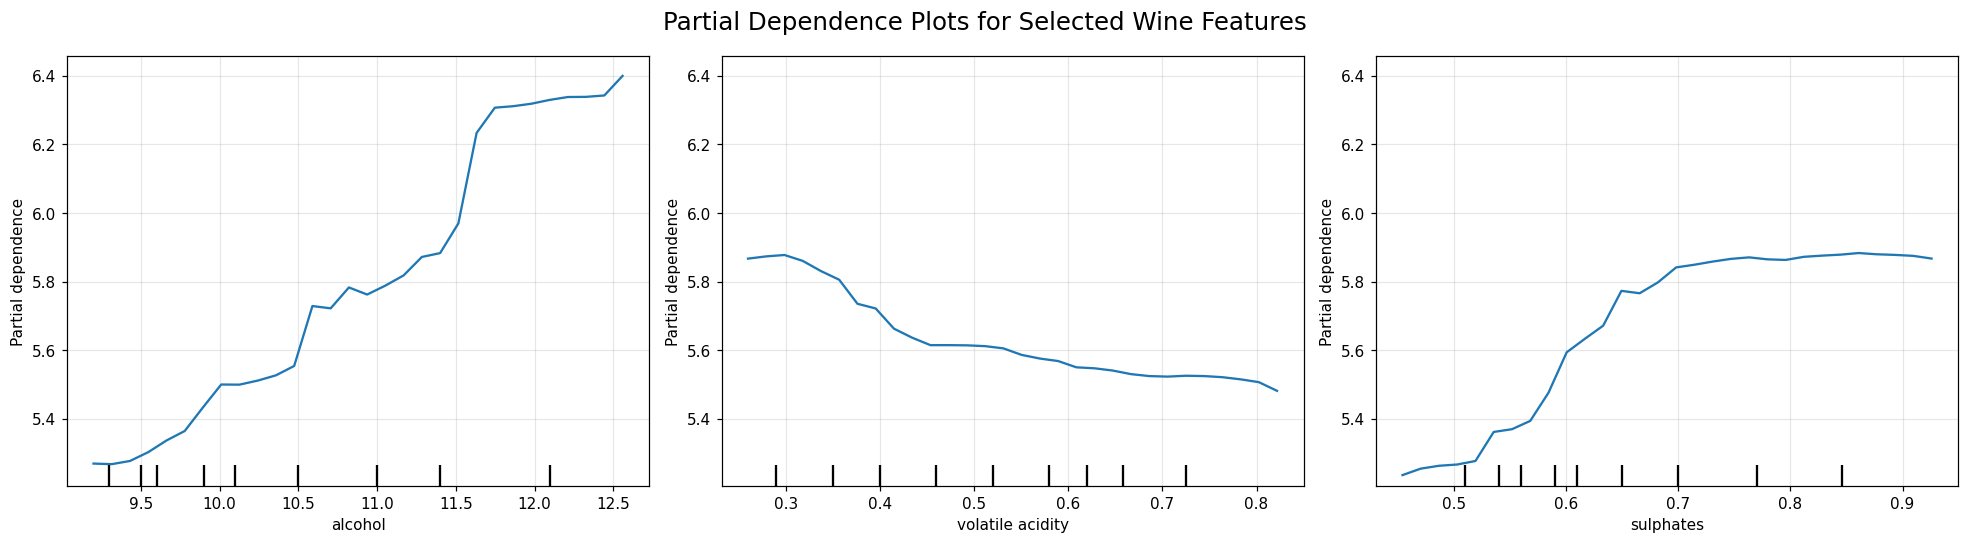

In [22]:
# Features selected for Partial Dependence Plots
pdp_features = [
    "alcohol",
    "volatile acidity",
    "sulphates"
]

# Generate horizontal PDPs
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=pdp_features,
    kind="average",
    grid_resolution=30,
    ax=axes
)

plt.suptitle(
    "Partial Dependence Plots for Selected Wine Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Task 4: Individual Conditional Expectation (ICE)

Generate ICE plots for:

* `alcohol`
* `volatile acidity`
* `sulphates`

Use at least **10 individual wine samples**.

**Comment:**

Explain how the prediction changes for each individual sample as the selected feature changes. Compare the individual curves with the overall PDP trend.


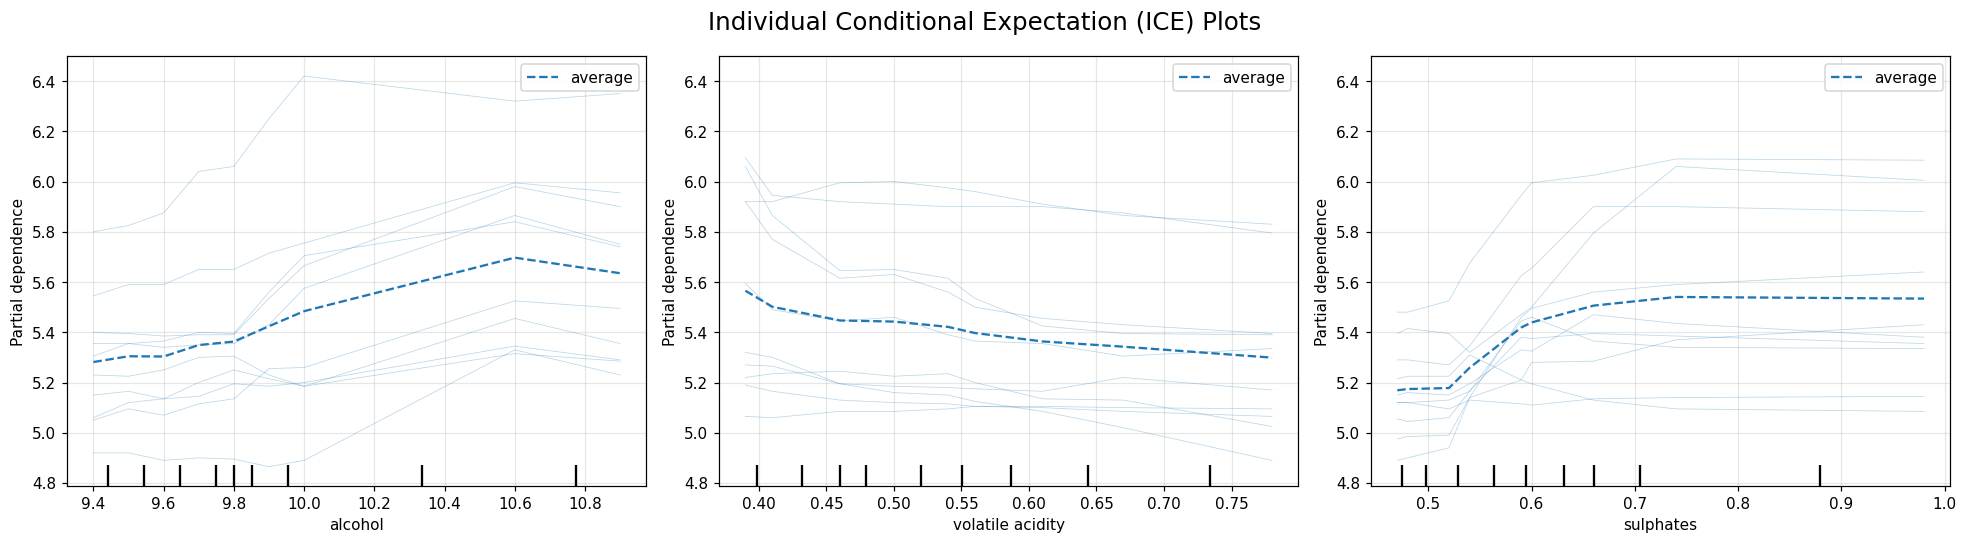

In [24]:
# Select at least 10 individual wine samples
ice_sample = X_test.iloc[:10]

# Generate ICE plots for the three selected features
ice_features = [
    "alcohol",
    "volatile acidity",
    "sulphates"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

PartialDependenceDisplay.from_estimator(
    model,
    ice_sample,
    features=ice_features,
    kind="both",
    grid_resolution=30,
    ax=axes
)

plt.suptitle(
    "Individual Conditional Expectation (ICE) Plots",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Task 5: Permutation Feature Importance (PFI)

Calculate PFI for **all input features**.

* Randomly shuffle one feature at a time.
* Measure the decrease in model performance.
* Rank the features according to their PFI scores.
* Display the results using a bar chart.

**Comment:**

Identify which features are most important to the model based on the decrease in performance after permutation.

In [25]:
# Calculate Permutation Feature Importance
pfi_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

# Create PFI results table
pfi_table = pd.DataFrame({
    "Feature": X_test.columns,
    "PFI Mean": pfi_result.importances_mean,
    "PFI Std": pfi_result.importances_std
})

# Rank features by PFI score
pfi_table = pfi_table.sort_values(
    by="PFI Mean",
    ascending=False
).reset_index(drop=True)

print("Permutation Feature Importance:")
display(pfi_table)


Permutation Feature Importance:


,Feature,PFI Mean,PFI Std
0,alcohol,0.383628,0.032568
1,sulphates,0.243227,0.022478
2,volatile acidity,0.137699,0.015996
3,total sulfur dioxide,0.071583,0.013334
4,pH,0.029063,0.006865
5,density,0.026423,0.004635
6,fixed acidity,0.025494,0.004864
7,free sulfur dioxide,0.023415,0.006452
8,chlorides,0.016484,0.006655
9,residual sugar,0.013135,0.004619


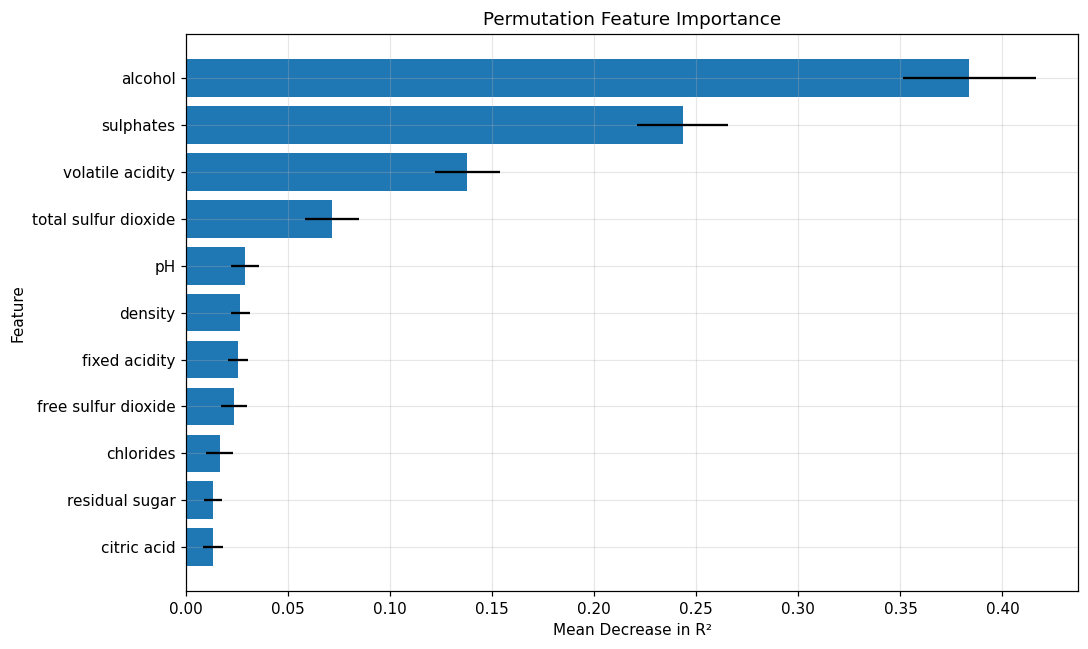

In [26]:
# Plot PFI scores
plt.figure(figsize=(10, 6))

plt.barh(
    pfi_table["Feature"],
    pfi_table["PFI Mean"],
    xerr=pfi_table["PFI Std"]
)

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


### Task 6: Compare PDP, ICE, and PFI

Compare the results obtained from all three XAI techniques.

Discuss:

1. Which features are most influential?
2. What is the relationship between the important features and the prediction?
3. Is the relationship linear or nonlinear?
4. Do individual ICE curves follow the average PDP trend?
5. Are there differences between individual samples?
6. Does the PFI ranking agree with the PDP and ICE observations?

### Discussion

The results from Partial Dependence Plots (PDP), Individual Conditional Expectation (ICE), and Permutation Feature Importance (PFI) are compared to understand both the importance and behavior of the wine-quality features.

#### 1. Most Influential Features

Based on the Permutation Feature Importance (PFI) results, alcohol is the most influential feature, followed by sulphates and volatile acidity. Alcohol has the highest mean decrease in R
2
, indicating that randomly permuting it causes the largest reduction in model performance. Sulphates and volatile acidity are the next most important features. The remaining features have considerably smaller PFI values.

#### 2. What is the relationship between the important features and the prediction?

The PDP results show that alcohol has a strong positive relationship with predicted wine quality. As alcohol increases, the predicted quality generally increases, with a particularly noticeable increase around the higher alcohol values.

For volatile acidity, the relationship is generally negative. As volatile acidity increases, the predicted wine quality gradually decreases.

For sulphates, the predicted quality generally increases as sulphates increase, particularly between approximately 0.55 and 0.70, after which the curve becomes relatively stable.

####3. Is the relationship linear or nonlinear?

The relationships are nonlinear rather than strictly linear. The PDP curves do not form straight lines with constant slopes. For example, the effect of alcohol becomes considerably stronger at higher values, while the sulphates curve increases and then reaches a relatively stable region. Volatile acidity also shows a gradual decrease with changes in slope across its range. Therefore, the model captures varying effects of the features rather than assuming a constant linear relationship.

#### 4. Do individual ICE curves follow the average PDP trend?

The ICE plots show that the individual curves generally follow the overall PDP trends, but they do not all behave identically.

For alcohol, most individual curves show an increasing prediction as alcohol increases, which is consistent with the positive PDP trend.

For volatile acidity, most curves show a decreasing tendency, consistent with the PDP.

For sulphates, several individual curves show an increase in prediction followed by stabilization, although the magnitude of the change differs between samples.

Thus, the PDP represents the average behavior, while ICE reveals the variation between individual wine samples.
#### 5. Are there differences between individual samples?

Yes. The ICE plots clearly show differences between individual wine samples. The curves are spread across different prediction levels and their slopes are not identical.

For example, when alcohol changes, some samples show a strong increase in predicted quality while others show a smaller change. Similar variation can be observed for volatile acidity and sulphates. This indicates that the effect of a feature can depend on the characteristics of the individual wine sample.
#### 6. Does the PFI ranking agree with the PDP and ICE observations?

Yes, the results are broadly consistent. PFI identifies alcohol, sulphates, and volatile acidity as the three most important features. These same features show noticeable prediction changes in the PDP plots and visible variations across individual samples in the ICE plots.

Alcohol has the highest PFI score and also shows a strong positive PDP trend. Sulphates has the second-highest PFI score and shows a noticeable increasing relationship before reaching a plateau. Volatile acidity ranks third in PFI and shows a clear negative PDP trend. Therefore, the three XAI techniques provide complementary but consistent evidence about the importance and behavior of these features.

### Final Observation

The experiment demonstrates how PDP, ICE, and PFI provide complementary explanations of the trained Random Forest Regression model for wine quality prediction. PFI identified alcohol as the most influential feature, followed by sulphates and volatile acidity. The PDP results showed that alcohol and sulphates generally have positive effects on predicted wine quality, whereas volatile acidity has a negative effect. The curves were nonlinear, indicating that the effect of a feature is not constant across its entire range. The ICE plots further showed that individual wine samples can respond differently to changes in the same feature, although their overall trends generally agree with the PDP results. Therefore, combining PDP, ICE, and PFI provides both global and individual-level understanding of the model's behavior and feature importance.